# Week 3. Preprocessing - From Diagnosis to a Deployable Recipe

The EDA notebook diagnosed the data: which columns are missing and why (MCAR vs. MNAR), which values are invalid, which categories need normalizing, which rows are duplicates, which columns are redundant. This notebook builds the fix - and it's a *recipe*, not a one-off cleanup: every step here has to survive being run again on data this pipeline has never seen, at inference time, without the target column present.

**Where this goes next:** by the end, this becomes `src/preprocessing.py` - same file as week 2, it grows into this rather than being replaced — plus a `preprocessing` section in `config.yaml`, in the hands-on part of class - see "From this notebook to the pipeline" at the end.

## The one-line rule

*From the split onward, the held-out rows exist to imitate the future-— every preprocessing decision may look only at the training rows.*

Not "fit on everything, split later"-— the encoder's category list, the scaler's mean and standard deviation, the imputed median, all of it gets learned **from the training fold only**, then applied unchanged to whatever comes next (the test fold today; a brand-new defendant's record at inference time next month). Anything fit on the full dataset before splitting is quietly leaking information from rows the model is supposed to have never seen - an optimistic bias that won't show up as a bug, just as a number on the leaderboard that's a little too good to be true.

## Deployable from day one

Two habits, established now instead of retrofitted later: every encoder is built with `handle_unknown="ignore"` (a category that shows up for the first time at inference time doesn't crash the pipeline, it just contributes nothing informative), and nothing in the preprocessing function *requires* the target column to be present — the same code has to run on unlabeled data being scored for real, not just on this week's labeled training file.

In [1]:
#you may need to install some new libraries. Use the command 'pip insta....':
# !pip install category_encoders

In [2]:
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from category_encoders import CountEncoder, TargetEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

BLUE = "#5EDDF3"
ORANGE = "#F78441"
GRAY = "#8E9196"
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["font.size"] = 10.5

with open("../data/diagnosis_log.json") as f:
    diagnosis = json.load(f)

diagnosis

{'source_file': '../data/compas_two_year_recidivism.csv',
 'n_rows_raw': 7286,
 'missingness_verdicts': {'age': 'MCAR',
  'juv_fel_count': 'MCAR',
  'priors_count': 'MNAR',
  'c_charge_degree': 'MNAR',
  'race': 'MCAR',
  'sex': 'MCAR'},
 'domain_rules': {'age': '18 <= age <= 100',
  'decile_score': '1 <= decile_score <= 10',
  'juv_fel_count': 'juv_fel_count >= 0',
  'priors_count': '0 <= priors_count <= 60'},
 'placeholder_tokens': ['', '-', '?', 'N/A', 'NA', 'n/a', 'na'],
 'canonical_maps': {'sex': {'male': 'Male', 'female': 'Female'},
  'race': {'african-american': 'African-American',
   'african american': 'African-American',
   'caucasian': 'Caucasian',
   'hispanic': 'Hispanic',
   'other': 'Other',
   'asian': 'Asian',
   'native american': 'Native American'},
  'c_charge_degree': {'f': 'F', 'felony': 'F', 'm': 'M', 'misdemeanor': 'M'},
  'score_text': {'low': 'Low', 'medium': 'Medium', 'high': 'High'}},
 'columns_to_drop': ['prior_offenses',
  'age_in_months',
  'juvenile_tota

That's this week's diagnosis, loaded straight from the EDA notebook - nothing below is re-derived from scratch, it's read off this log. If the EDA notebook's findings ever change (a new week's data, a re-run diagnosis), this notebook's recipe changes with it automatically instead of silently going stale.

## Step 1 - a `clean_dataset` function

Everything the EDA notebook found, applied as one deterministic function: canonicalize categories, convert placeholders and domain-rule violations to `NaN`, drop duplicate rows, drop the redundant columns. This runs on the **whole** dataset (train + test together) because none of it is target-dependent or fit-dependent - canonicalizing `"MALE"` to `"Male"` doesn't learn anything from the data that could leak. Anything that *is* fit-dependent (imputing a median, fitting an encoder) waits until after the split, in Step 2.

In [4]:
def find_placeholder_rows(series: pd.Series, tokens: set) -> pd.Series:
    return series.astype(str).str.strip().isin(tokens)


def canonicalize_categories(df: pd.DataFrame, columns_and_maps: dict, placeholder_tokens: set) -> pd.DataFrame:
    out = df.copy()
    for col, mapping in columns_and_maps.items():
        cleaned = out[col].astype(str).str.strip()
        lowered = cleaned.str.lower()
        out[col] = lowered.map(mapping).fillna(cleaned)
        out.loc[out[col].astype(str).str.strip().isin(placeholder_tokens), col] = np.nan
    return out


def clean_dataset(df: pd.DataFrame, diagnosis: dict) -> pd.DataFrame:
    """
    Apply the EDA notebook's diagnosis: category cleanup, domain-rule / placeholder ->
    NaN conversion, de-duplication, redundant-column removal. Target-column-agnostic --
    safe to call on label-free inference data.
    """
    out = df.copy()
    placeholder_tokens = set(diagnosis["placeholder_tokens"])

    # numeric columns that loaded as text because of placeholder tokens
    for col in ["priors_count", "prior_offenses"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col].replace(list(placeholder_tokens), np.nan), errors="coerce")

    # domain-rule violations -> NaN
    out.loc[out["age"].notna() & ~out["age"].between(18, 100), "age"] = np.nan
    out.loc[~out["decile_score"].between(1, 10), "decile_score"] = np.nan
    out.loc[out["juv_fel_count"].notna() & (out["juv_fel_count"] < 0), "juv_fel_count"] = np.nan
    out.loc[out["priors_count"].notna() & ((out["priors_count"] < 0) | (out["priors_count"] > 60)), "priors_count"] = np.nan

    # category canonicalization (also folds placeholder tokens in race/sex/c_charge_degree/score_text to NaN)
    out = canonicalize_categories(out, diagnosis["canonical_maps"], placeholder_tokens)

    # duplicates: exact row dupes and repeated ids point at the same rows here -- drop, keep first
    out = out.drop_duplicates()
    if "id" in out.columns:
        out = out.drop_duplicates(subset="id", keep="first")

    # redundant columns found via multicollinearity
    cols_to_drop = [c for c in diagnosis["columns_to_drop"] if c in out.columns and c != "id"]
    out = out.drop(columns=cols_to_drop)

    return out


df_raw = pd.read_csv("../data/compas_two_year_recidivism.csv")
df_clean = clean_dataset(df_raw, diagnosis)
print(f"{len(df_raw)} rows -> {len(df_clean)} rows after cleaning ({len(df_raw) - len(df_clean)} duplicates dropped)")
print(f"{df_raw.shape[1]} columns -> {df_clean.shape[1]} columns ({df_raw.shape[1] - df_clean.shape[1]} redundant columns dropped)")
df_clean.head()

7286 rows -> 7214 rows after cleaning (72 duplicates dropped)
16 columns -> 13 columns (3 redundant columns dropped)


,juv_other_count,score_text,priors_count,juv_misd_count,sex,age_cat,id,c_charge_degree,two_year_recid,juv_fel_count,race,age,decile_score
0,1,Low,0.0,0,Male,25 - 45,8423,F,0,0.0,African-American,27.0,2.0
1,0,High,3.0,0,Male,Less than 25,4137,M,1,0.0,Caucasian,23.0,8.0
2,0,Low,2.0,0,Male,25 - 45,5064,F,1,0.0,Caucasian,28.0,2.0
3,0,High,2.0,0,Female,Less than 25,56,F,0,NaN,African-American,21.0,8.0
4,0,Low,1.0,0,Male,25 - 45,9369,M,0,0.0,African-American,31.0,4.0


## Step 2 - imputation, matched to mechanism

This is where the MCAR-vs-MNAR verdict actually earns its keep. A column that's missing completely at random can be filled with its median or mode and nothing is lost-— there's no pattern to preserve. A column whose missingness is tangled up with another variable (`priors_count`, `c_charge_degree`) is different: naively filling it with the overall median would erase a real signal (*whether it's missing at all* correlates with something). Not sophisticated enough yet to properly model that relationship (that's weeks 8–9's job, once the pipeline has the proximity-imputation and MICE machinery) - but a defensible middle ground exists today: **impute the value, and also keep a `_was_missing` flag alongside it**, so a model can still pick up on the pattern even though the fill value itself is just a median or mode.

This step has to be **fit on train only** - the median used to fill a column is computed from the training rows, then applied to test/inference rows unchanged, so it goes inside the same `ColumnTransformer` as everything else in Step 3, not run here on the full dataset. What *can* happen now, target-agnostically, is deciding *which* strategy each column gets:

In [5]:
IMPUTATION_PLAN = {
    # MCAR -- simple fill, no indicator needed
    "age": {"strategy": "median", "indicator": False},
    "juv_fel_count": {"strategy": "median", "indicator": False},
    "race": {"strategy": "most_frequent", "indicator": False},
    "sex": {"strategy": "most_frequent", "indicator": False},
    # MNAR -- fill AND flag, so the model can still see that it was missing
    "priors_count": {"strategy": "median", "indicator": True},
    "c_charge_degree": {"strategy": "most_frequent", "indicator": True},
}
pd.DataFrame(IMPUTATION_PLAN).T.rename_axis("column")

,strategy,indicator
column,,
age,median,False
juv_fel_count,median,False
race,most_frequent,False
sex,most_frequent,False
priors_count,median,True
c_charge_degree,most_frequent,True


## Step 3 - a leak-safe, deployable `ColumnTransformer`

Feature set: everything except the target, the sensitive attribute (`race` - held aside, never a model input), COMPAS's own score (`decile_score`, `score_text`-— kept only for comparison), and `id`. Two MNAR columns get an extra `_was_missing` indicator column, added *before* the ColumnTransformer runs (a `FunctionTransformer` would work too, but doing it explicitly here keeps the indicator logic visible rather than hidden inside a black-box step).

In [6]:
TARGET = "two_year_recid"
SENSITIVE_ATTR = "race"
COMPAS_OWN_SCORE = ["decile_score", "score_text"]
DROP_ALWAYS = ["id", TARGET, SENSITIVE_ATTR] + COMPAS_OWN_SCORE

NUMERIC_FEATURES = ["age", "juv_fel_count", "juv_misd_count", "juv_other_count", "priors_count"]
CATEGORICAL_FEATURES = ["sex", "age_cat", "c_charge_degree"]
MNAR_INDICATOR_SOURCES = ["priors_count", "c_charge_degree"]


def add_missingness_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Adds a `<col>_was_missing` flag for each MNAR column, BEFORE that column gets imputed.
    Target-agnostic -- safe on label-free inference data."""
    out = df.copy()
    for col in MNAR_INDICATOR_SOURCES:
        out[f"{col}_was_missing"] = out[col].isna().astype(int)
    return out


def split_features_target(df: pd.DataFrame):
    """Splits into (X, y, extras). `y` is None and `extras` has no `two_year_recid`
    column when called on label-free inference data -- nothing downstream requires the target."""
    df = add_missingness_indicators(df)
    y = df[TARGET] if TARGET in df.columns else None
    extras_cols = [c for c in [SENSITIVE_ATTR, "score_text"] if c in df.columns]
    extras = df[extras_cols].copy() if extras_cols else None
    feature_cols = [c for c in df.columns if c not in DROP_ALWAYS]
    X = df[feature_cols]
    return X, y, extras


def build_preprocessor(encoder_name: str, scaler_name: str) -> ColumnTransformer:
    """Factory: builds a leak-safe ColumnTransformer for a given encoder/scaler choice.
    Every encoder tolerates unseen categories at transform time (handle_unknown='ignore'
    or its category_encoders equivalent) -- fit on train, applied unchanged to test/inference."""
    scalers = {
        "none": "passthrough",
        "standard": StandardScaler(),
        "minmax": MinMaxScaler(),
        "robust": RobustScaler(),
    }
    encoders = {
        "onehot": OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        "ordinal": OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        "count": CountEncoder(handle_unknown=0, handle_missing=0),
        "target": TargetEncoder(handle_unknown="value", handle_missing="value"),
    }

    numeric_indicator_cols = [f"{c}_was_missing" for c in MNAR_INDICATOR_SOURCES]
    numeric_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", scalers[scaler_name]),
    ])
    categorical_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", encoders[encoder_name]),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ("indicators", "passthrough", numeric_indicator_cols),
    ])


X_all, y_all, extras_all = split_features_target(df_clean)
print(X_all.shape, y_all.shape)
X_all.head()

(7214, 10) (7214,)


,juv_other_count,priors_count,juv_misd_count,sex,age_cat,c_charge_degree,juv_fel_count,age,priors_count_was_missing,c_charge_degree_was_missing
0,1,0.0,0,Male,25 - 45,F,0.0,27.0,0,0
1,0,3.0,0,Male,Less than 25,M,0.0,23.0,0,0
2,0,2.0,0,Male,25 - 45,F,0.0,28.0,0,0
3,0,2.0,0,Female,Less than 25,F,NaN,21.0,0,0
4,0,1.0,0,Male,25 - 45,M,0.0,31.0,0,0


Bellow, we leave other interesting things that you can test using or use as inspiration for building your own functions:

## Step 4 - choosing the encoder × scaler pair empirically

Four encoders × four scalers = 16 combinations. Rather than pick one by convention ("one-hot + standard scaling, because that's usually fine"), score all 16 with a real model across repeated splits and let the data decide - the same "don't assume, measure it" discipline as Technique 1's missingness test, just applied to a modeling choice instead of a data quirk. `LogisticRegression` is the right model to grid-search *with* here - it's the one scaling actually matters for (a decision tree, arriving next week, doesn't care). The scoring metric is plain **accuracy** for now.

**Why repeated splits, not one:** a single 75/25 split is one draw from a lot of possible ones - the "winner" from a single split could just be that split's luck. Repeating it 15 times with a different split each time and averaging is what makes the ranking trustworthy rather than a coin flip dressed up as a result.

In [8]:
ENCODERS = ["onehot", "ordinal", "count", "target"]
SCALERS = ["none", "standard", "minmax", "robust"]
N_REPEATS = 15

grid_rows = []
per_repeat_scores = {}   # (encoder, scaler) -> list of N_REPEATS accuracy scores, same split each repeat index
for encoder_name in ENCODERS:
    for scaler_name in SCALERS:
        scores = []
        for repeat in range(N_REPEATS):
            X_train, X_test, y_train, y_test = train_test_split(
                X_all, y_all, test_size=0.25, random_state=repeat, stratify=y_all
            )
            pipe = Pipeline([
                ("prep", build_preprocessor(encoder_name, scaler_name)),
                ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
            ])
            pipe.fit(X_train, y_train)
            pred = pipe.predict(X_test)
            scores.append(accuracy_score(y_test, pred))
        per_repeat_scores[(encoder_name, scaler_name)] = scores
        grid_rows.append({
            "encoder": encoder_name, "scaler": scaler_name,
            "mean_accuracy": np.mean(scores), "std_accuracy": np.std(scores),
        })

grid_results = pd.DataFrame(grid_rows).sort_values("mean_accuracy", ascending=False).reset_index(drop=True)
grid_results.assign(
    mean_accuracy=grid_results["mean_accuracy"].round(4),
    std_accuracy=grid_results["std_accuracy"].round(4),
)

,encoder,scaler,mean_accuracy,std_accuracy
0,target,standard,0.6704,0.0088
1,target,none,0.6703,0.0086
2,target,robust,0.6701,0.0090
3,onehot,none,0.6693,0.0087
4,onehot,robust,0.6693,0.0085
5,ordinal,robust,0.6691,0.0085
6,onehot,standard,0.6691,0.0085
7,ordinal,standard,0.6691,0.0085
8,ordinal,none,0.6690,0.0086
9,onehot,minmax,0.6685,0.0086


Winner: target encoding + standard scaling -- mean accuracy 0.6704 (+/- 0.0088 across 15 repeats)


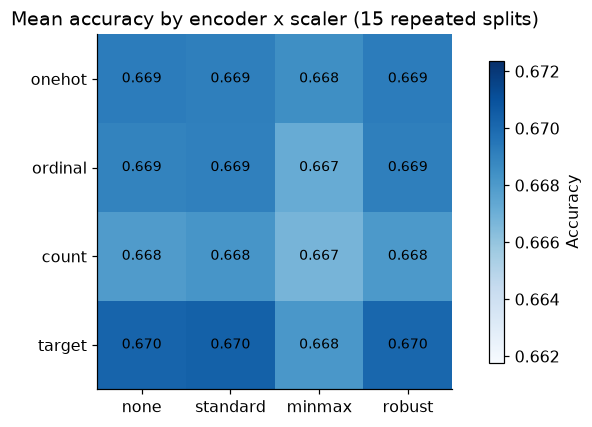

In [9]:
best = grid_results.iloc[0]
print(f"Winner: {best['encoder']} encoding + {best['scaler']} scaling "
      f"-- mean accuracy {best['mean_accuracy']:.4f} (+/- {best['std_accuracy']:.4f} across {N_REPEATS} repeats)")

fig, ax = plt.subplots(figsize=(7, 4))
pivot = grid_results.pivot(index="encoder", columns="scaler", values="mean_accuracy")
pivot = pivot[SCALERS].loc[ENCODERS]
im = ax.imshow(pivot.values, cmap="Blues", vmin=pivot.values.min() - 0.005, vmax=pivot.values.max() + 0.002)
ax.set_xticks(range(len(SCALERS)), SCALERS)
ax.set_yticks(range(len(ENCODERS)), ENCODERS)
for i in range(len(ENCODERS)):
    for j in range(len(SCALERS)):
        ax.text(j, i, f"{pivot.values[i,j]:.3f}", ha="center", va="center", fontsize=9)
ax.set_title("Mean accuracy by encoder x scaler (15 repeated splits)")
fig.colorbar(im, ax=ax, label="Accuracy", shrink=0.85)
plt.tight_layout()
plt.show()

The gap between the best and worst pair is real but not enormous - logistic regression is fairly forgiving of scaling choice once the categorical encoding is reasonable. Worth noting *why* this makes sense: decision trees and their descendants (week 4 onward) don't need scaling at all, since a threshold split is invariant to monotonic rescaling-— this grid is doing real work specifically because this week's baseline is still a scaling-sensitive linear model.

## Step 5 - is the winner actually better, or is this noise?

A mean that's 0.001 higher isn't automatically a real difference - it could easily be within the noise of which 15 particular splits got drawn. The right way to check: since every combination was scored on the *same* 15 splits (`random_state=repeat` is identical across the inner loop), the winner and the runner-up can be compared **on a per-split basis**, not just by comparing their two mean columns. That's a *paired* comparison.

In [10]:
winner_key = (best["encoder"], best["scaler"])
runner_up = grid_results.iloc[1]
runner_up_key = (runner_up["encoder"], runner_up["scaler"])

winner_scores = np.array(per_repeat_scores[winner_key])
runner_up_scores = np.array(per_repeat_scores[runner_up_key])

# paired difference: same split index -> same train/test rows for both, so subtracting
# per-split is a fair like-for-like comparison, not just "mean A minus mean B"
diffs = winner_scores - runner_up_scores
mean_diff = diffs.mean()
se_diff = diffs.std(ddof=1) / np.sqrt(len(diffs))   # standard error of the paired difference

print(f"Winner:     {winner_key[0]} + {winner_key[1]}  (mean accuracy {winner_scores.mean():.4f})")
print(f"Runner-up:  {runner_up_key[0]} + {runner_up_key[1]}  (mean accuracy {runner_up_scores.mean():.4f})")
print(f"Paired mean difference: {mean_diff:+.4f}  (SE {se_diff:.4f}, over {len(diffs)} paired splits)")

if abs(mean_diff) > 2 * se_diff:
    print("-> more than 2 standard errors from zero: a real, if modest, edge -- not just split luck.")
else:
    print("-> within about 2 standard errors of zero: could easily be noise. Either pair would be a defensible choice; "
          "the grid still picks one so the pipeline has a single answer, not because the gap is decisive.")

Winner:     target + standard  (mean accuracy 0.6704)
Runner-up:  target + none  (mean accuracy 0.6703)
Paired mean difference: +0.0001  (SE 0.0002, over 15 paired splits)
-> within about 2 standard errors of zero: could easily be noise. Either pair would be a defensible choice; the grid still picks one so the pipeline has a single answer, not because the gap is decisive.


This is a small preview of a bigger idea: **"is A actually better than B" is a question about the *distribution* of the difference, not just about which single number is bigger.** Two models scored once each can look different purely by luck of the split; the same two models compared over many *paired* splits either keep showing the same gap (real) or the gap wanders around zero (noise). 

**Regression**- the paired-comparison logic here doesn't care whether the underlying score is accuracy, ROC-AUC, or (for a continuous target) RMSE/MAE/R² - "same splits, subtract, look at the spread of the differences" transfers unchanged. What *would* change for a regression target is the scoring metric feeding into it, and, per the one-line rule above, everything upstream of the split staying exactly as leak-safe as it is here.

**Important Note**: When implementing a Grid Search like we do for the encoder x scaler, you need to be carefull about the possibility of introducing **data leakedge**! For this week, this will be ignored. Once we introduce the concepts of Cross-Validation, Nested Cross-Validation, etc... to our pipeline, we'll study how to tune our preprocessing and models eithout introducing leakedge!

## From this notebook to the pipeline

**Where to add:** everything below lands in `src/preprocessing.py` - the same file week 2 started with one job (the split); this week it grows to own the whole "raw data in, model-ready split out" job, rather than spreading that across files.

| Function | What it does | Pulled from |
|---|---|---|
| `clean_dataset(df, diagnosis)` | category cleanup, domain-rule/placeholder → `NaN`, de-dup, drop redundant columns | Step 1, unchanged |
| `add_missingness_indicators(df)` | adds `<col>_was_missing` flags for the MNAR columns | Step 3, unchanged |
| `split_features_target(df)` | returns `(X, y, extras)`; `y` is `None` on label-free data | Step 3, unchanged |
| `build_preprocessor(encoder_name, scaler_name)` | the leak-safe `ColumnTransformer` factory | Step 3, unchanged |
| `split_train_test(X, y, extras, ...)` | the stratified train/test split — week 2's original job, still here | week 2, unchanged |

**What doesn't change this week:** `src/evaluate.py` - no new metrics land there yet (F1 score, ROC-AUC/PR-AUC and a calibration check are coming, just not this week).

**What changes in `config.yaml`:** a new `preprocessing` section, holding this week's chosen encoder/scaler pair (whichever the grid above actually picked -- read it off the `grid_results` table, don't hardcode a guess) and the imputation plan, so nothing above stays hardcoded in Python:
```yaml
preprocessing:
  encoder: "<this week's winner from the grid above>"
  scaler: "<this week's winner from the grid above>"
  imputation:
    age: {strategy: median, indicator: false}
    juv_fel_count: {strategy: median, indicator: false}
    race: {strategy: most_frequent, indicator: false}
    sex: {strategy: most_frequent, indicator: false}
    priors_count: {strategy: median, indicator: true}
    c_charge_degree: {strategy: most_frequent, indicator: true}

data:
  drop_columns: ["id", "decile_score", "score_text", "prior_offenses", "age_in_months", "juvenile_total"]
```

**What changes in `main.py`:** swap the call from the old `preprocess()` to `clean_dataset()` → `split_features_target()` → `build_preprocessor()` inside a `Pipeline` with the model, reading the encoder/scaler names from `config.yaml["preprocessing"]` instead of hardcoding them.

## Update your README

Part of this week's goal is drafting a real structure for your project README — not just name + student number, but something that can carry the pipeline's decisions forward as it grows. A reasonable structure to start from, building on what's already there:

```markdown
# <Your  name>

## Overview
What the project predicts, and why it's interesting.

## Pipeline progress
(This is the running log of what changed and why, week by week.)

## Preprocessing decisions         
For each column that needed a decision, one line: what was wrong, what mechanism (MCAR/MNAR/
domain rule/duplicate), what was done about it, and why. This is your `verdict table`, in prose --
whoever reads your README next (including future-you) shouldn't have to re-derive it from the code.

## Best Model
Comparison between your models, results and current best model

```

You can adjust the structure to your liking, as long as you keep a log of what you worked on and updated in your pipeline each week and current best model.

## Challenge - how far can you push this?

Now that we have reviewed EDA and introduced a more complete preprocessing pipeline, its time for you to explore these changes!

1. Is there any other missing value treatment you believe could be more relevant in this pipeline (e.g. KNN Imputer, constant, etc...)? If so, test your pipeline with this imputer and see what changes in your models!
2. Did you find any other issues in the data, not discussed in notebook 1.eda_introduction? If you, add them to your cleaning pipeline!
3. Compare your preprocessed models with the previous models from week 2. Does the preprocessing improve model results and why? What is your current top model?